In [1]:
import numpy as np
import pandas as pd
import torch

import seaborn as sns
import matplotlib.pyplot as plt

/home/bini/.conda/envs/pygda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
result_dir = "../../__saved__/results/evaluation/161858_process_datasets.csv"
result_dir = "../../__saved__/results/evaluation/161948_compare_role_types.csv"
result_dir = "../../__saved__/results/evaluation/161910_process_datasets.csv"
df1 = pd.read_csv(result_dir)
df1

,micro_f1,macro_f1,source,target,model,seed,train_time,repeat,cur_time
0,0.703526,0.710547,Citationv1,ACMv9,SimGDA_Role,0,37.109793,0,161911
1,0.741612,0.723940,Citationv1,DBLPv7,SimGDA_Role,0,35.409280,0,161911
2,0.724790,0.693740,DBLPv7,Citationv1,SimGDA_Role,0,35.491558,0,161912
3,0.655021,0.659046,DBLPv7,ACMv9,SimGDA_Role,0,36.181749,0,161912
4,0.676389,0.686002,Citationv1,ACMv9,GNN,0,6.280522,0,161912
5,0.732859,0.709694,Citationv1,DBLPv7,GNN,0,7.254038,0,161913
6,0.711360,0.684811,DBLPv7,Citationv1,GNN,0,6.381366,0,161913
7,0.630556,0.626495,DBLPv7,ACMv9,GNN,0,6.377457,0,161913
8,0.692521,0.701216,Citationv1,ACMv9,SimGDA,0,33.689780,0,161913
9,0.741430,0.723813,Citationv1,DBLPv7,SimGDA,0,33.361429,0,161914


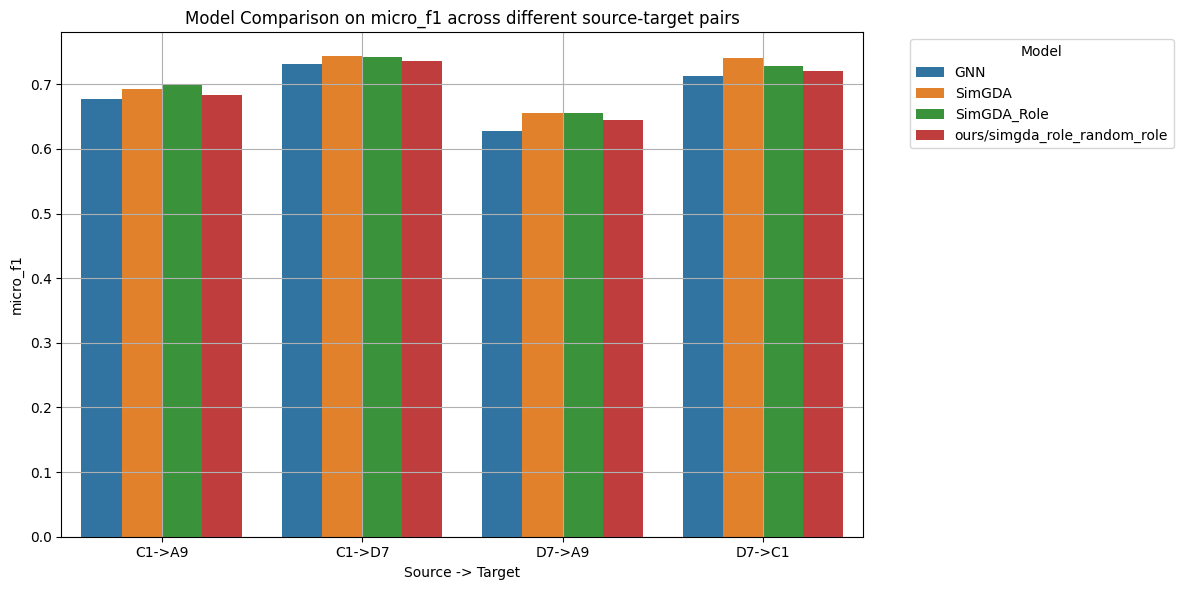

In [3]:
metrics = ["micro_f1", "macro_f1"]
plot_metric = metrics[0]  # choose metric to plot

df1["s->t"] = df1["source"].str[0] + df1["source"].str[-1] + "->" + df1["target"].str[0] + df1["target"].str[-1]

# let's compare each model on each s->t (group by s->t and model)
grouped_df1 = df1.groupby(["s->t", "model"])[plot_metric].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_df1, x="s->t", y=plot_metric, hue="model")
plt.title(f"Model Comparison on {plot_metric} across different source-target pairs")
plt.ylabel(plot_metric)
plt.xlabel("Source -> Target")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

Summary Table (Mean ± Std across seeds):


,s->t,model,micro_f1_mean,micro_f1_std,macro_f1_mean,macro_f1_std
0,C1->A9,GNN,0.6776,0.0017,0.6840,0.0029
1,C1->A9,SimGDA,0.6929,0.0005,0.7007,0.0007
2,C1->A9,SimGDA_Role,0.7006,0.0041,0.7073,0.0046
3,C1->A9,ours/simgda_role_random_role,0.6829,0.0005,0.6865,0.0013
4,C1->D7,GNN,0.7319,0.0013,0.7088,0.0013
5,C1->D7,SimGDA,0.7433,0.0027,0.7255,0.0024
6,C1->D7,SimGDA_Role,0.7431,0.0021,0.7245,0.0008
7,C1->D7,ours/simgda_role_random_role,0.7360,0.0018,0.7145,0.0013
8,D7->A9,GNN,0.6274,0.0045,0.6207,0.0081
9,D7->A9,SimGDA,0.6561,0.0038,0.6659,0.0006


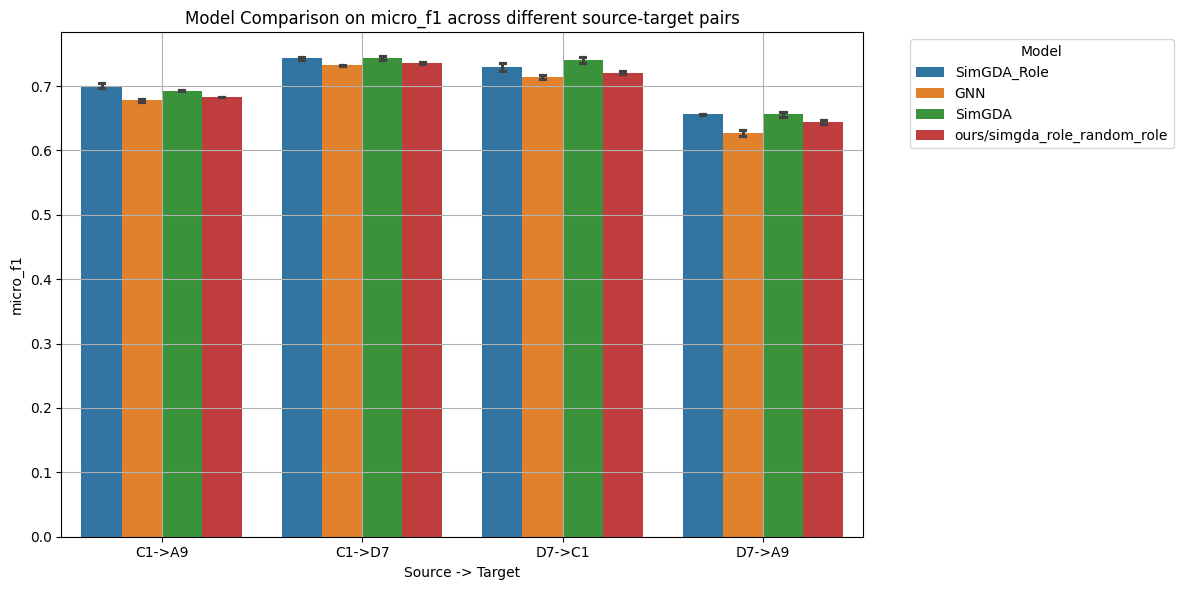

In [4]:
metrics = ["micro_f1", "macro_f1"]
plot_metric = metrics[0]  # choose metric to plot

df1["s->t"] = df1["source"].str[0] + df1["source"].str[-1] + "->" + df1["target"].str[0] + df1["target"].str[-1]

# Create summary table with mean and std for each metric
summary_table = df1.groupby(["s->t", "model"]).agg(
    {m: ["mean", "std"] for m in metrics}
).round(4)

# Flatten column names
summary_table.columns = [f"{m}_{stat}" for m, stat in summary_table.columns]
summary_table = summary_table.reset_index()

print("Summary Table (Mean ± Std across seeds):")
display(summary_table)

# Create grouped data for plotting
grouped_df1 = df1.groupby(["s->t", "model"])[plot_metric].agg(["mean", "std"]).reset_index()

# Plot with error bars
plt.figure(figsize=(12, 6))
sns.barplot(data=df1, x="s->t", y=plot_metric, hue="model", errorbar="sd", capsize=0.1)
plt.title(f"Model Comparison on {plot_metric} across different source-target pairs")
plt.ylabel(plot_metric)
plt.xlabel("Source -> Target")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
# [-1, 2, 1, 10]
# label_diffusion = 4xk
# let's say you have 4 classes, [0.1, 0.2, 0.1, 0.6] 
# x = [1, 0] [0, 1], [0, 1] [0, 1], [0, 1]

# logits = f(x, a)

# argmax = np.argmax(label_diffusion[0])
# role = label_diffusion[argmax, :] # 1xk
